In [ ]:
import os
os.environ["KMP_DUPLICATE_LIB_OK"] = "TRUE"  # Prevents OpenMP conflicts on some platforms

import numpy as np
import torch
import torchvision.datasets as datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

try:
    import gudhi
except:
    !pip install gudhi
    import gudhi

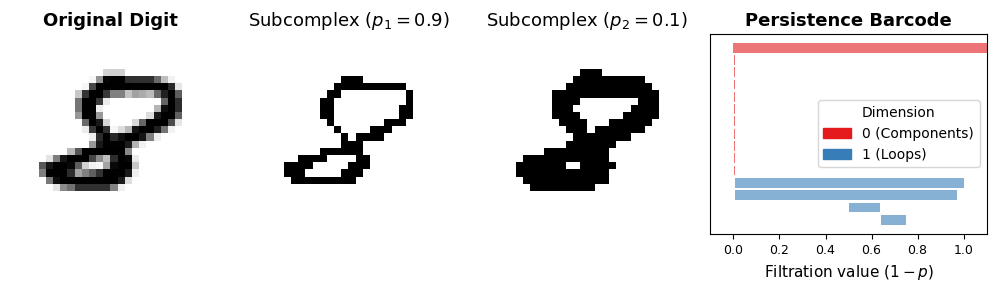

In [21]:
transform = v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
test_set = datasets.MNIST(root="./mnist_data", train=False, download=False, transform=transform)

img_8 = None
for img, label in test_set:
    if label == 8:
        img_8 = img.squeeze().numpy()
        break

inv_img = 1.0 - img_8
cubical_complex = gudhi.CubicalComplex(
    dimensions=inv_img.shape, 
    top_dimensional_cells=inv_img.flatten()
)
diag = cubical_complex.persistence()

# The barcode gets 1.8x the width of the 3 square images
fig, axes = plt.subplots(
    1, 4, 
    figsize=(10, 2.8), 
    gridspec_kw={"width_ratios": [1, 1, 1, 1.2]}, 
    constrained_layout=True
)

axes[0].imshow(img_8, cmap="gray_r")
axes[0].set_title("Original Digit", fontsize=13, fontweight="bold")
axes[0].axis("off")

tau_1 = 0.90
axes[1].imshow(img_8 >= tau_1, cmap="binary")
axes[1].set_title(f"Subcomplex ($p_1 = {tau_1}$)", fontsize=13)
axes[1].axis("off")

tau_2 = 0.10
axes[2].imshow(img_8 >= tau_2, cmap="binary")
axes[2].set_title(f"Subcomplex ($p_2 = {tau_2}$)", fontsize=13)
axes[2].axis("off")

gudhi.plot_persistence_barcode(diag, axes=axes[3], legend=True)
axes[3].set_title("Persistence Barcode", fontsize=13, fontweight="bold")
axes[3].set_xlabel("Filtration value ($1 - p$)", fontsize=11)
axes[3].tick_params(axis="x", labelsize=9)

leg = axes[3].get_legend()
for text, new_label in zip(leg.get_texts(), ["0 (Components)", "1 (Loops)"]):
    text.set_text(new_label)

plt.savefig("mnist_cubical_barcode.pdf", bbox_inches="tight")
plt.show()